## Import Packages

In [46]:
import os
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import rankdata, norm, spearmanr, t
from scipy.interpolate import UnivariateSpline
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from pandas.plotting import register_matplotlib_converters
from sklearn.model_selection import KFold
from sklearn.metrics import silhouette_score
import xgboost as xgb
from sklearn.model_selection import train_test_split
from statsmodels.tsa.seasonal import STL
register_matplotlib_converters()

## CONFIGURATION

In [47]:
CSV_PATH = "wedowind.csv"
TEST_PERIOD_DAYS = 20
RANDOM_STATE = 42
FI_THRESHOLD = 70.0

# Binary error code for failure detection
FAILURE_CODE = 1

In [ ]:
# List of all candidate variables for machine learning-based selection
CANDIDATE_VARS = [
    'airpressure', 'humidity', 'bearing_temperature', 'temp_environment',
    'gear_pressure', 'nacelle_direction', 'wind_direction',
    'hydraulic_pressure', 'blade_angle_2', 'blade_angle_1',
    'cosphi', 'wind_speed', 'turbulence_intensity',
    'power', 'rotor_speed', 'generator_speed', 'temp_hydraulic_oil',
    'blade_angle_3', 'generator_temperature'
]

### Load and Pre-process data

[Step 2] Mahalanobis filter kept 506376 / 521729 (97.1%)


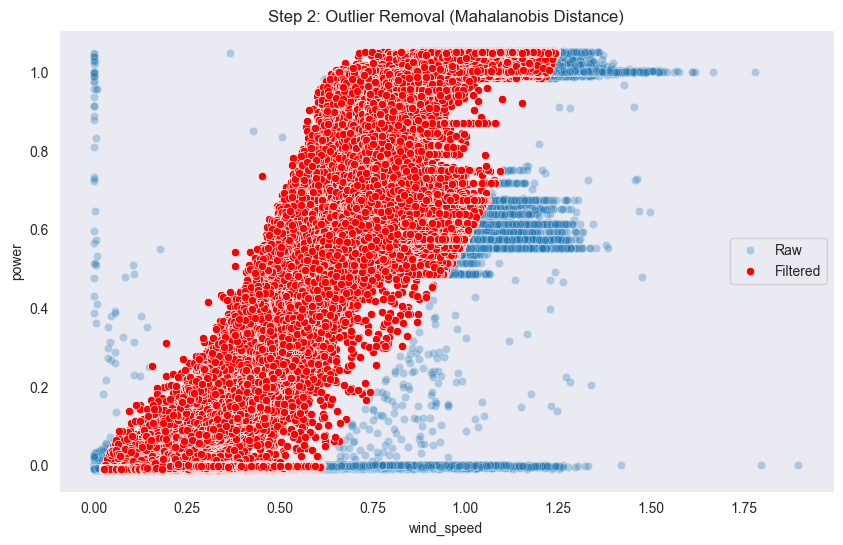

[Step 1] Loaded data: 506376 rows, 23 columns
Final dictionary of last failure dates: {np.int64(109): Timestamp('2022-07-25 13:00:00'), np.int64(115): Timestamp('2022-07-28 13:00:00'), np.int64(120): Timestamp('2022-07-20 07:20:00'), np.int64(114): Timestamp('2022-07-18 13:00:00'), np.int64(116): Timestamp('2022-07-28 13:00:00')}


In [52]:
def load_and_preprocess_data(csv_path):
    data = pd.read_csv(csv_path, parse_dates=['timestamp'])
    if 'Unnamed: 0' in data.columns:
        data.drop(columns=['Unnamed: 0'], inplace=True)
    if 'plant_name' not in data.columns or 'errorcode' not in data.columns:
        raise KeyError("The CSV file must contain 'plant_name' and 'errorcode' columns.")
    data.set_index('timestamp', inplace=True)
    data.sort_index(inplace=True)
    return data

def find_last_failure_dates(data, failure_code):
    last_failure_dates = {}
    unique_plants = data['plant_name'].unique()
    for plant_name in unique_plants:
        plant_df = data[data['plant_name'] == plant_name].copy()
        failure_events = plant_df[plant_df['errorcode'] == failure_code]
        if not failure_events.empty:
            last_event_date = failure_events.index.max()
            last_failure_dates[plant_name] = last_event_date
    return last_failure_dates

def clean_data(df):
    df_clean = df.copy()
    key_vars = ['power', 'wind_speed', 'rotor_speed']
    df_clean = df_clean.dropna(subset=key_vars, how='any')
    df_clean = df_clean[
        (df_clean['power'] >= 0) &
        (df_clean['rotor_speed'] >= 0) &
        (df_clean['wind_speed'] >= 0)
    ]
    return df_clean

def mahalanobis(x, mean, inv_cov):
    return np.sqrt((x - mean).T @ inv_cov @ (x - mean))

def filter_outliers(df, variables, threshold=3.0):
    cov = np.cov(df[variables].T)
    inv_cov = np.linalg.inv(cov)
    mean = np.mean(df[variables], axis=0)
    distances = [mahalanobis(row, mean, inv_cov) for _, row in df[variables].iterrows()]
    return df[np.array(distances) < threshold]

variables_to_filter = ['power', 'wind_speed']
filtered = filter_outliers(data, variables_to_filter, threshold=3.0)

print(f"[Step 2] Mahalanobis filter kept {filtered.shape[0]} / {data.shape[0]} ({100*filtered.shape[0]/data.shape[0]:.1f}%)")

plt.figure(figsize=(10, 6))
sns.scatterplot(x='wind_speed', y='power', data=data, label='Raw', alpha=0.3)
sns.scatterplot(x='wind_speed', y='power', data=filtered, label='Filtered', color='red')
plt.title('Step 2: Outlier Removal (Mahalanobis Distance)')
plt.legend()
plt.grid()
plt.show()

# Use the filtered data for all subsequent steps
data = filtered
last_failure_dates = find_last_failure_dates(data, FAILURE_CODE)
print(f"[Step 1] Loaded data: {data.shape[0]} rows, {data.shape[1]} columns")
print(f"Final dictionary of last failure dates: {last_failure_dates}")


### Feature Selection with XGBoost

In [53]:
def select_features_for_plant(plant_df, candidate_vars, failure_date):
    data_ml = plant_df.copy()
    data_ml['failure_imminent'] = 0
    pre_failure_start = failure_date - pd.Timedelta(days=10)
    data_ml.loc[pre_failure_start:failure_date, 'failure_imminent'] = 1

    ml_features = [v for v in candidate_vars if v in data_ml.columns and data_ml[v].nunique() > 1]
    ml_data = data_ml[ml_features + ['failure_imminent']].dropna()
    X = ml_data[ml_features]
    y = ml_data['failure_imminent']

    if not X.empty and not y.empty and len(np.unique(y)) > 1:
        X_train, _, y_train, _ = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)
        model = xgb.XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_STATE)
        model.fit(X_train, y_train)
        importances = model.feature_importances_
        feature_importances = pd.Series(importances, index=X.columns).sort_values(ascending=False)
        selected_features = list(feature_importances.head(10).index)
        print(f"Selected top 10 features for {plant_df['plant_name'].iloc[0]}: {selected_features}")
        return selected_features
    else:
        print(f"Not enough data for XGBoost feature selection for {plant_df['plant_name'].iloc[0]}.")
        return None

plant_specific_features = {
    plant: select_features_for_plant(data[data['plant_name'] == plant], CANDIDATE_VARS, failure_date)
    for plant, failure_date in last_failure_dates.items()
}

Selected top 10 features for 109: ['generator_temperature', 'gear_pressure', 'cosphi', 'wind_speed', 'blade_angle_2', 'humidity', 'power', 'bearing_temperature', 'temp_environment', 'blade_angle_3']
Selected top 10 features for 115: ['airpressure', 'generator_temperature', 'cosphi', 'power', 'blade_angle_3', 'humidity', 'rotor_speed', 'bearing_temperature', 'wind_speed', 'generator_speed']
Selected top 10 features for 120: ['rotor_speed', 'nacelle_direction', 'generator_temperature', 'temp_environment', 'bearing_temperature', 'hydraulic_pressure', 'cosphi', 'airpressure', 'power', 'wind_direction']
Selected top 10 features for 114: ['power', 'nacelle_direction', 'cosphi', 'generator_speed', 'rotor_speed', 'blade_angle_3', 'temp_environment', 'airpressure', 'bearing_temperature', 'wind_direction']
Selected top 10 features for 116: ['power', 'airpressure', 'generator_speed', 'bearing_temperature', 'cosphi', 'temp_hydraulic_oil', 'generator_temperature', 'blade_angle_2', 'blade_angle_3', 

### Main Processing and Visualization Loop

In [57]:
def generalized_esd_test(series, alpha=0.05, max_anomalies_percent=0.15):
    """
    Applies the generalized ESD test to a time series.
    """
    series_copy = series.copy().dropna()
    anomalies_idx = []

    n = len(series_copy)
    if n == 0:
        return []

    r = int(np.floor(n * max_anomalies_percent))

    for i in range(r):
        median_T = series_copy.median()
        mad = np.median(np.abs(series_copy - median_T))

        if mad == 0:
            break

        test_statistic = np.abs(series_copy - median_T) / mad
        max_idx_loc = np.argmax(test_statistic)
        max_idx = series_copy.index[max_idx_loc]

        test_stat_val = test_statistic.iloc[max_idx_loc]

        p = n - i
        critical_value = (p) * t.ppf(1 - alpha / (2 * p), p - 1) / np.sqrt((p - 1) + t.ppf(1 - alpha / (2 * p), p - 1)**2)

        if test_stat_val > critical_value:
            anomalies_idx.append(max_idx)
            series_copy.drop(index=max_idx, inplace=True)
        else:
            break

    return anomalies_idx

def esd_anomaly_detection(series, period_s=864, window_s_multiple=2):
    """
    Performs anomaly detection using time series decomposition and generalized ESD.
    """
    if len(series) < period_s * window_s_multiple:
        return pd.Series()

    decomposition = STL(series, period=period_s, robust=True, seasonal=13).fit()
    series_residual = decomposition.resid

    anomaly_indices = generalized_esd_test(series_residual)
    return series.loc[anomaly_indices]

Optimal number of GMM components based on BIC: 5

======== Processing Plant: 109 (Failure Date: 2022-07-25 13:00:00) ========


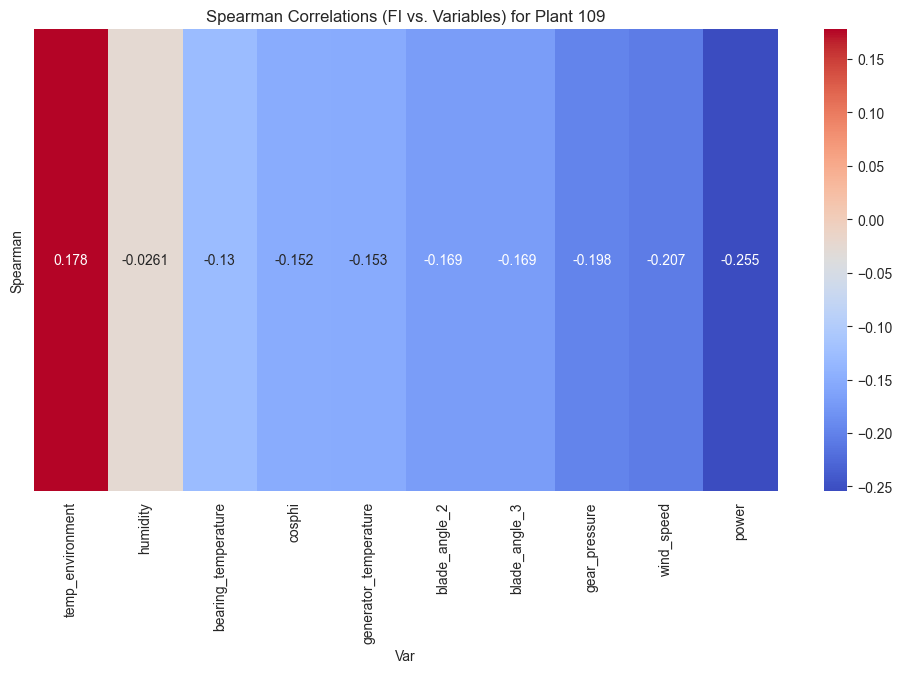

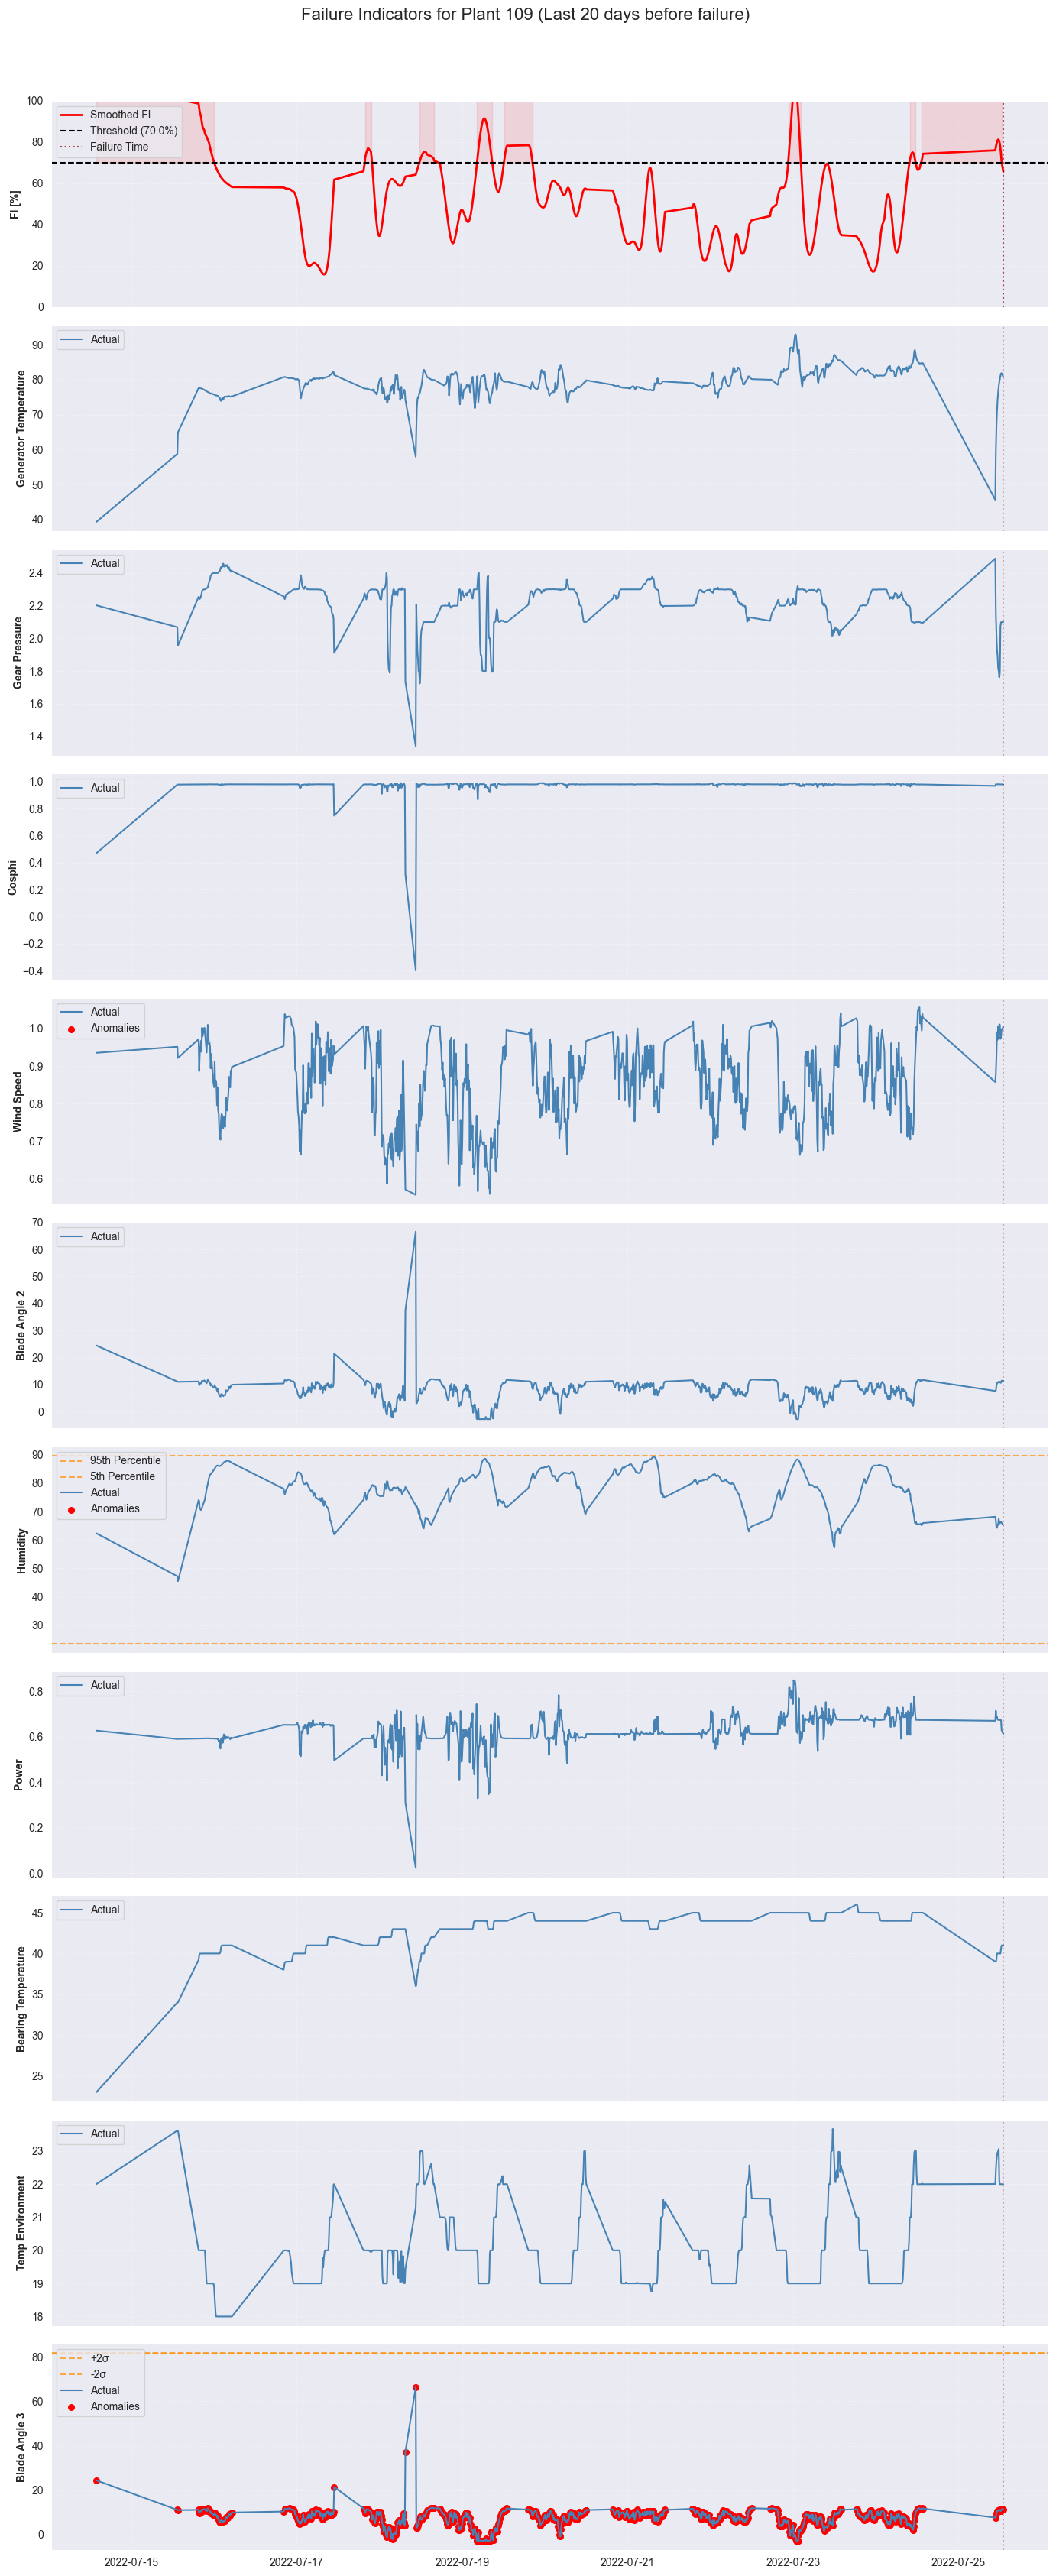


Key statistics near failure:
       generator_temperature  gear_pressure     cosphi  wind_speed  \
count              16.000000      16.000000  16.000000   16.000000   
mean               75.633935       2.020062   0.978899    0.978248   
std                10.600280       0.184200   0.002873    0.050387   
min                45.664501       1.761593   0.968395    0.857688   
25%                73.341894       1.872529   0.978895    0.972031   
50%                79.714149       2.083427   0.979824    0.992350   
75%                81.790611       2.098960   0.979935    1.007089   
max                84.734352       2.488462   0.981042    1.039596   

       blade_angle_2   humidity      power  bearing_temperature  \
count      16.000000  16.000000  16.000000            16.000000   
mean       10.566758  65.899168   0.671777            40.927089   
std         1.239903   1.024131   0.022672             2.100129   
min         7.642383  64.286697   0.613201            39.000000   
25% 

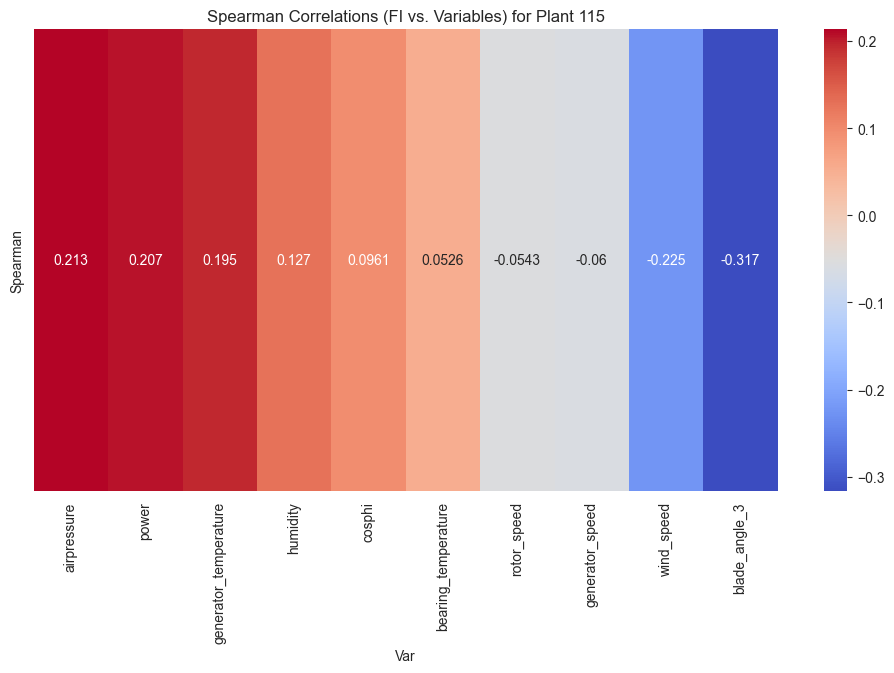

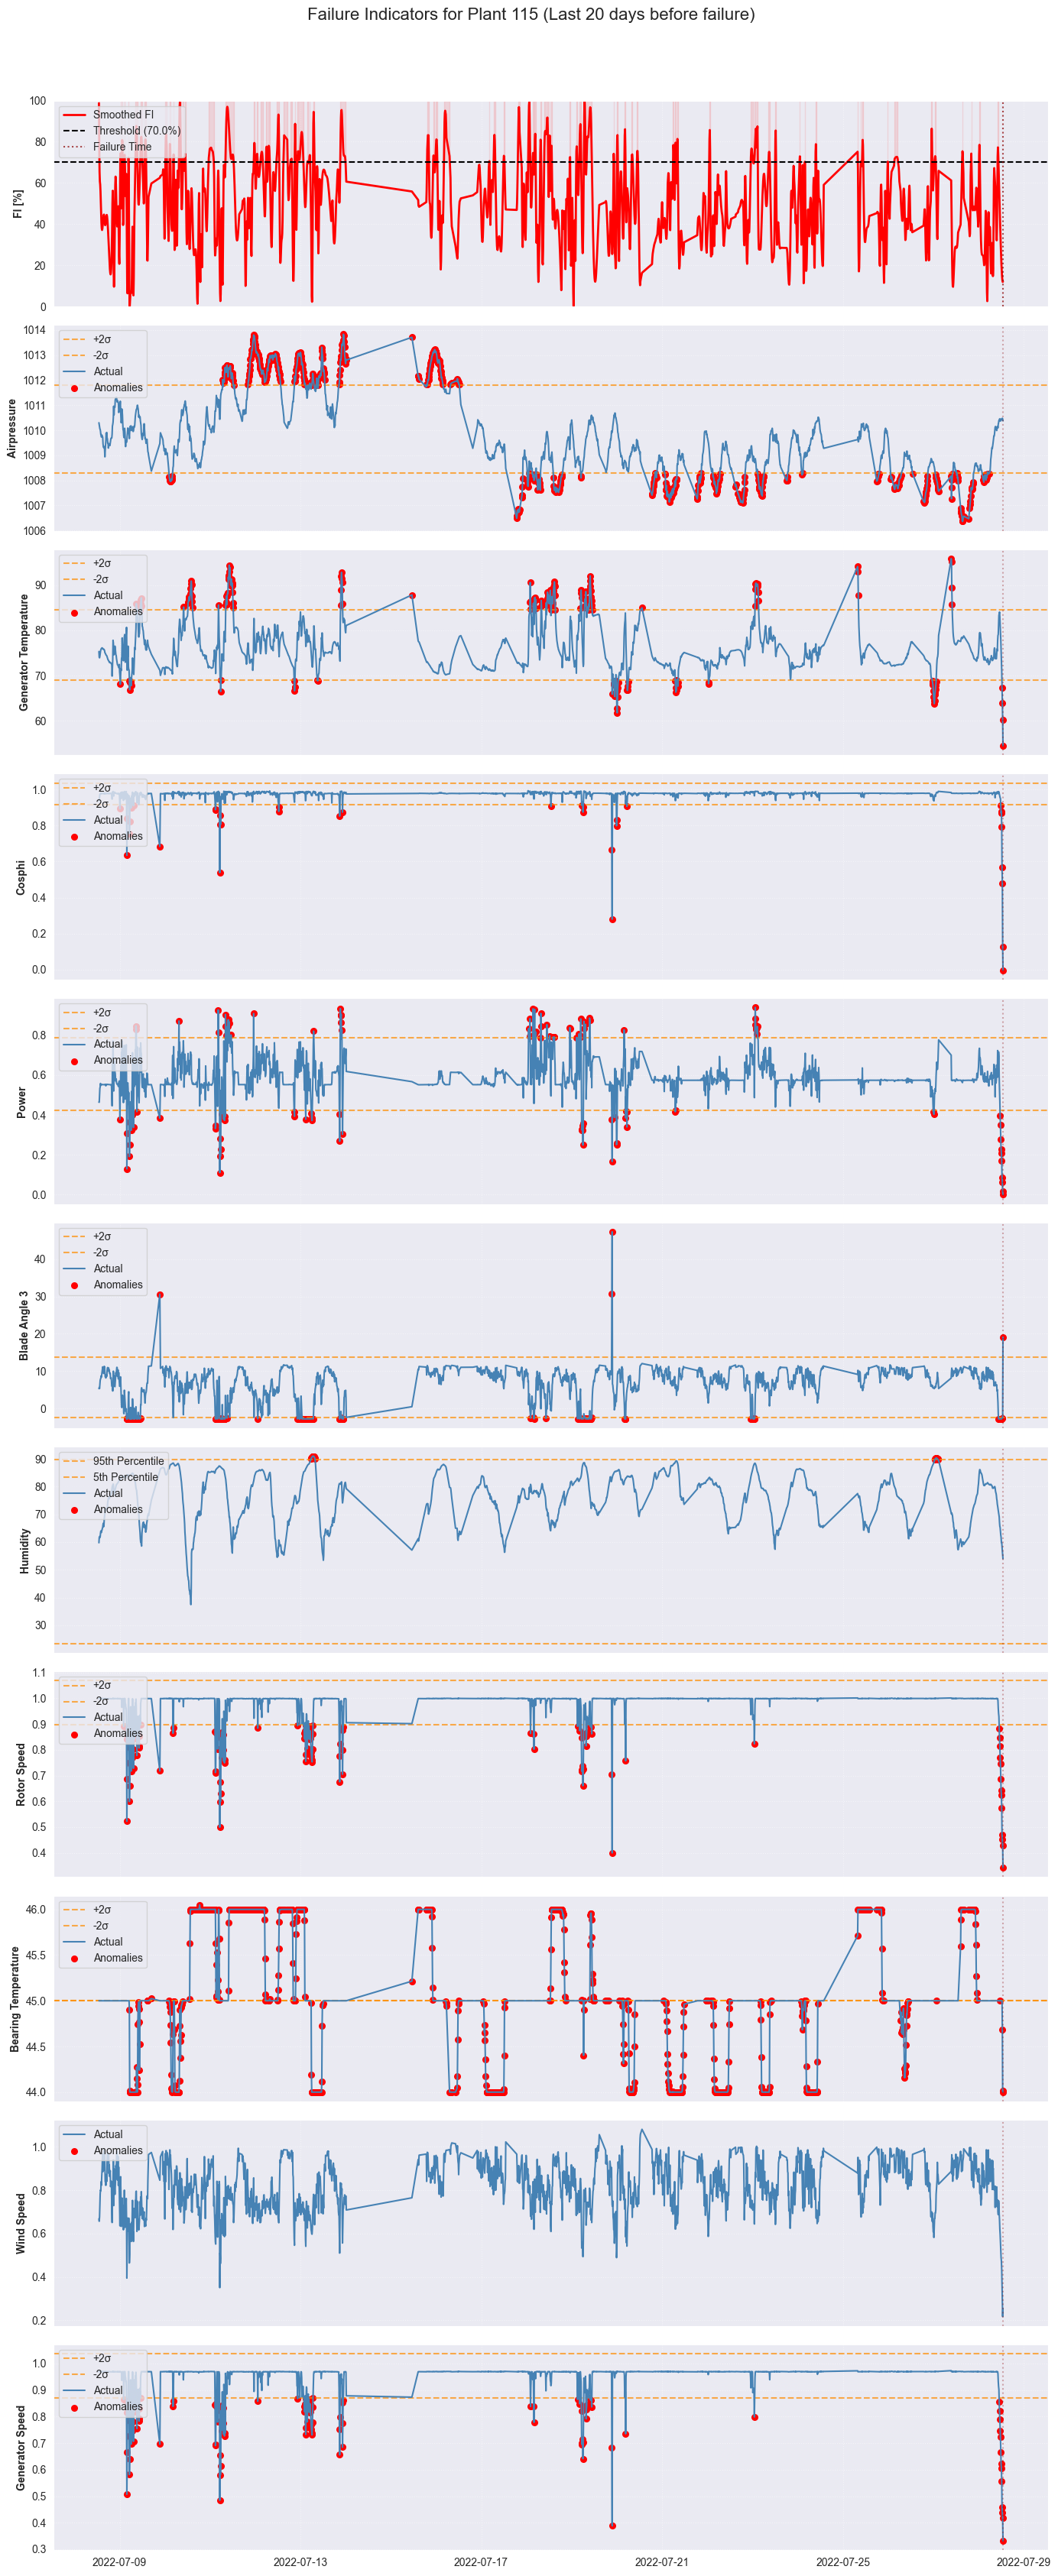


Key statistics near failure:
       airpressure  generator_temperature      cosphi       power  \
count   114.000000             114.000000  114.000000  114.000000   
mean   1008.677982              75.060958    0.951134    0.558916   
std       1.149498               3.815855    0.135914    0.131177   
min    1006.359990              54.439968   -0.003711    0.000441   
25%    1008.107485              73.530680    0.978206    0.572603   
50%    1008.434995              74.330174    0.979483    0.576909   
75%    1009.770020              77.414181    0.980087    0.605920   
max    1010.479980              84.056168    0.990000    0.734500   

       blade_angle_3    humidity  rotor_speed  bearing_temperature  \
count     114.000000  114.000000   114.000000           114.000000   
mean        7.119060   74.165228     0.956198            45.236564   
std         4.335365    8.606313     0.128671             0.460262   
min        -2.827563   53.971001     0.342122            44.000000  

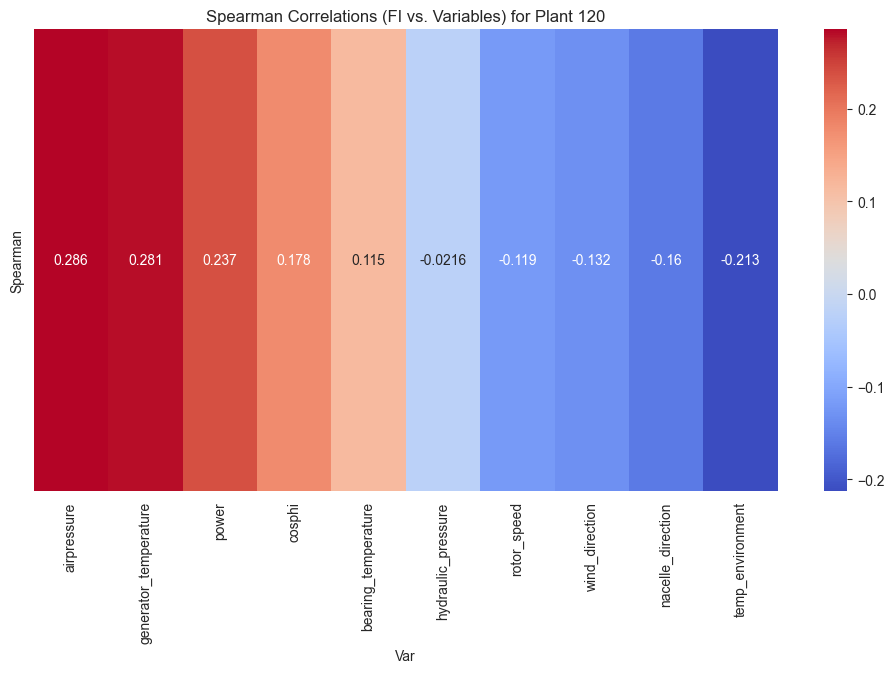

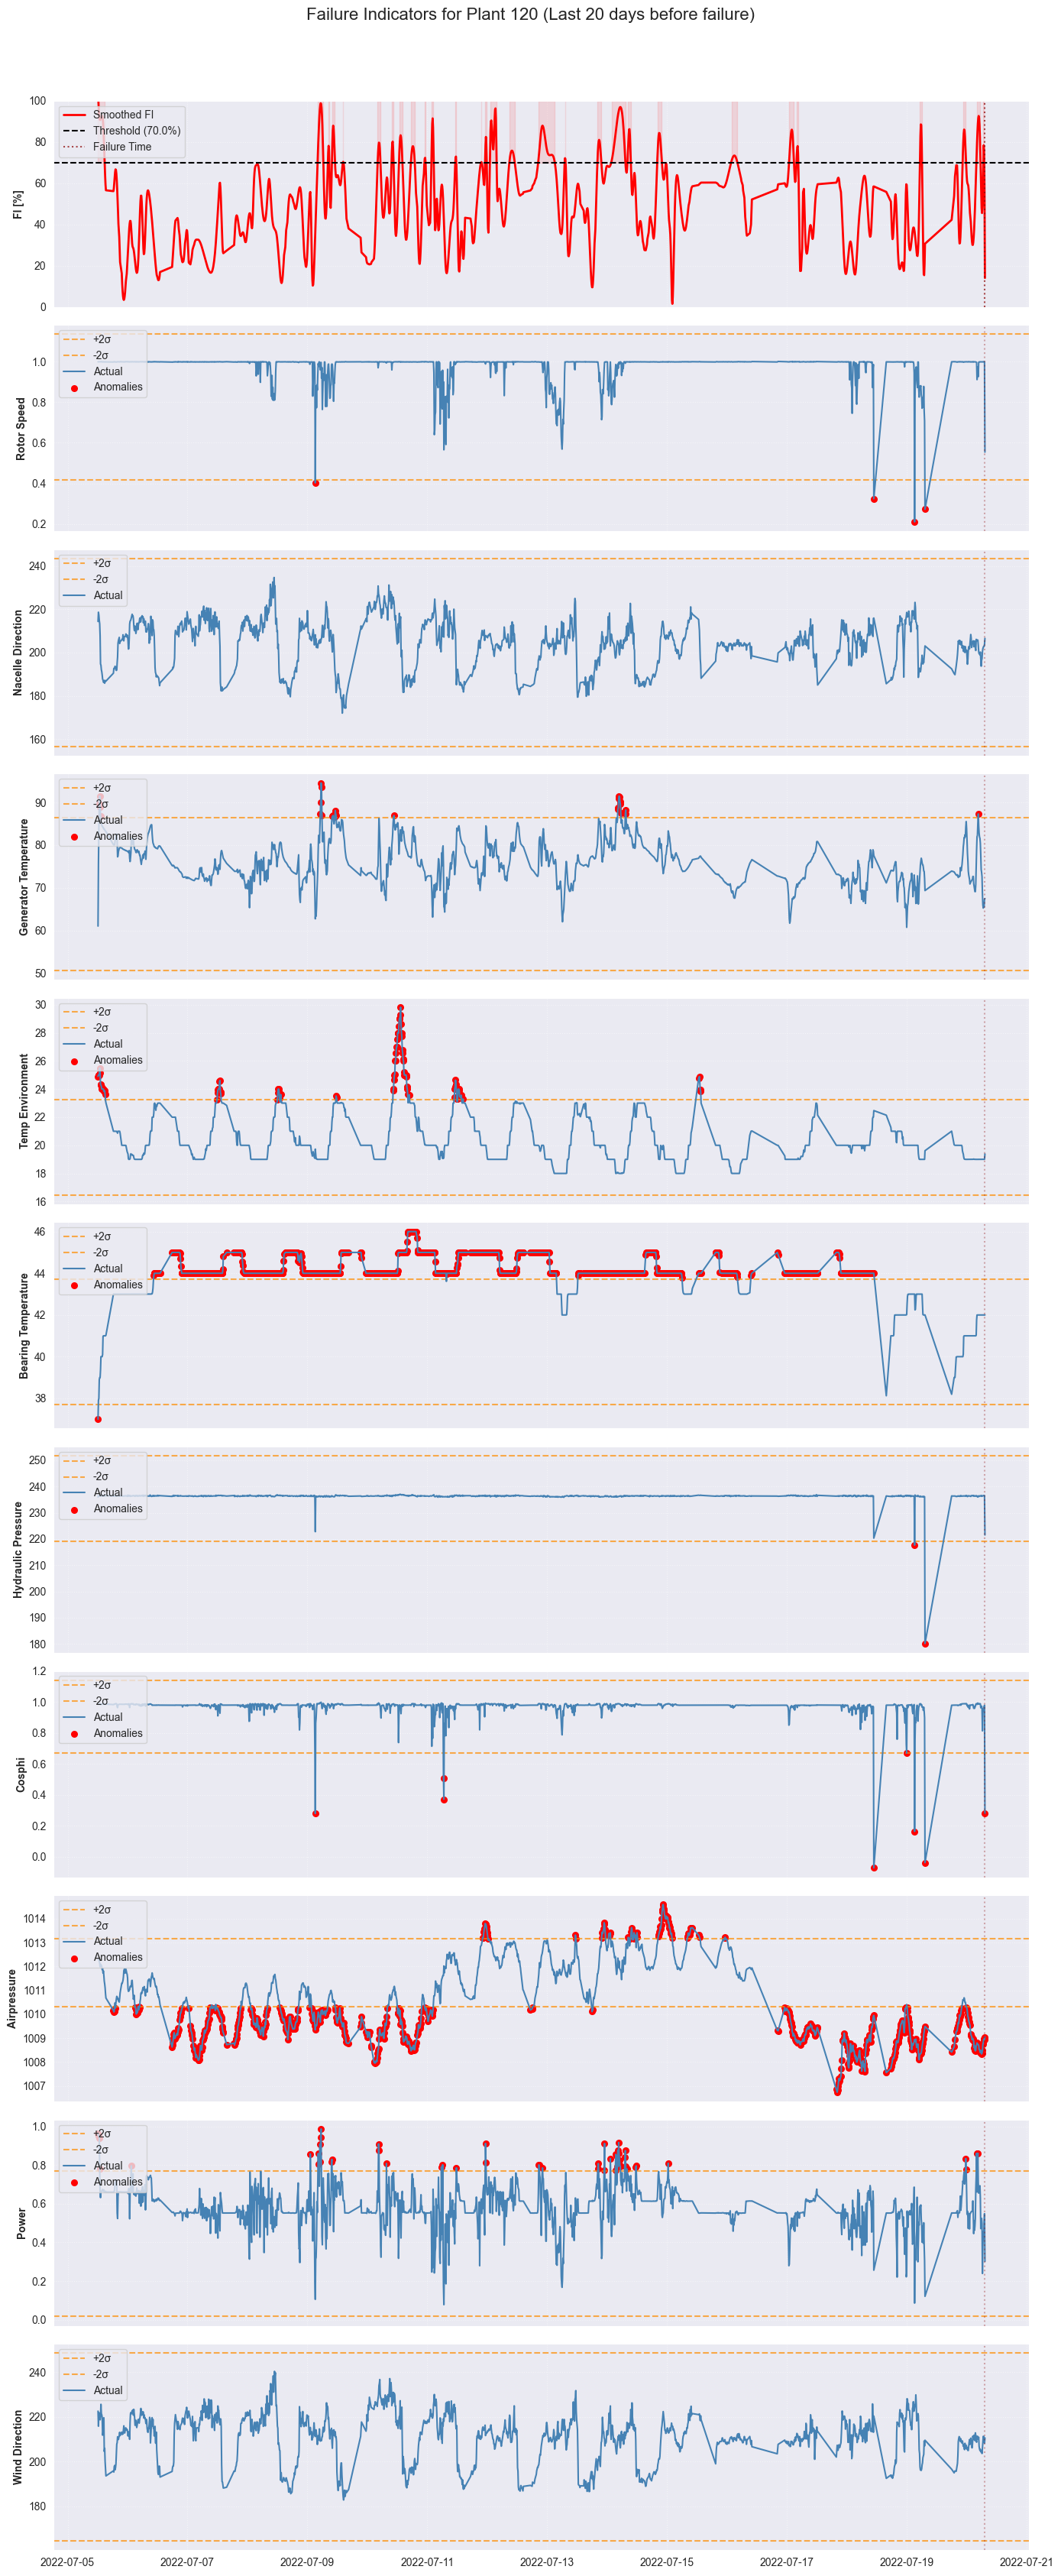


Key statistics near failure:
       rotor_speed  nacelle_direction  generator_temperature  \
count    71.000000          71.000000              71.000000   
mean      0.989038         201.608447              75.106381   
std       0.054606           3.864581               5.402501   
min       0.554224         189.759170              65.264801   
25%       0.998533         200.269065              71.914211   
50%       0.998857         202.389429              73.621582   
75%       0.999246         204.531714              80.007416   
max       0.999859         208.309780              87.292793   

       temp_environment  bearing_temperature  hydraulic_pressure     cosphi  \
count         71.000000            71.000000           71.000000  71.000000   
mean          19.283094            40.958398          236.149458   0.967216   
std            0.465414             0.871210            1.766582   0.085771   
min           19.000000            38.195850          221.502899   0.279939  

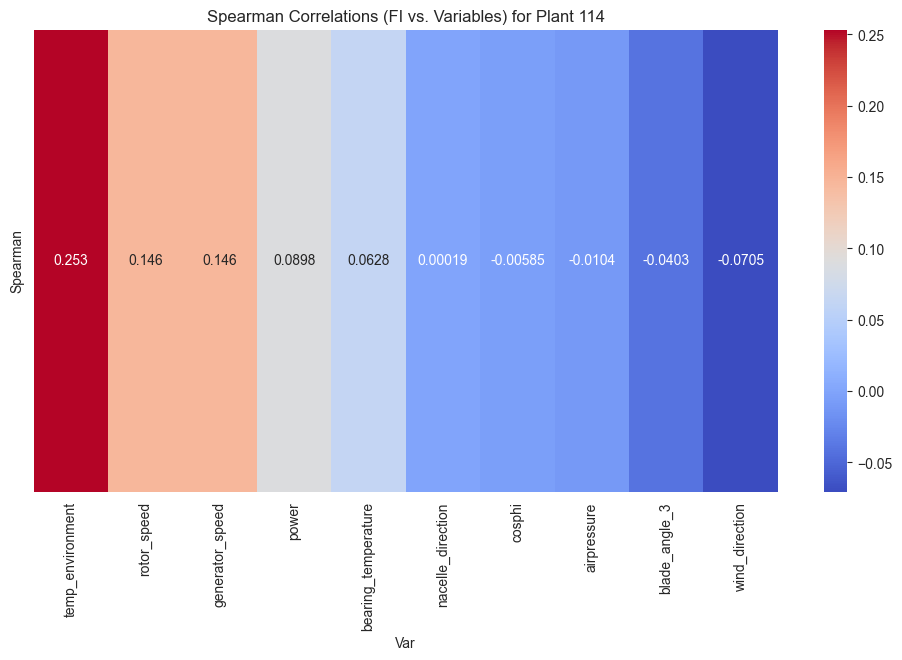

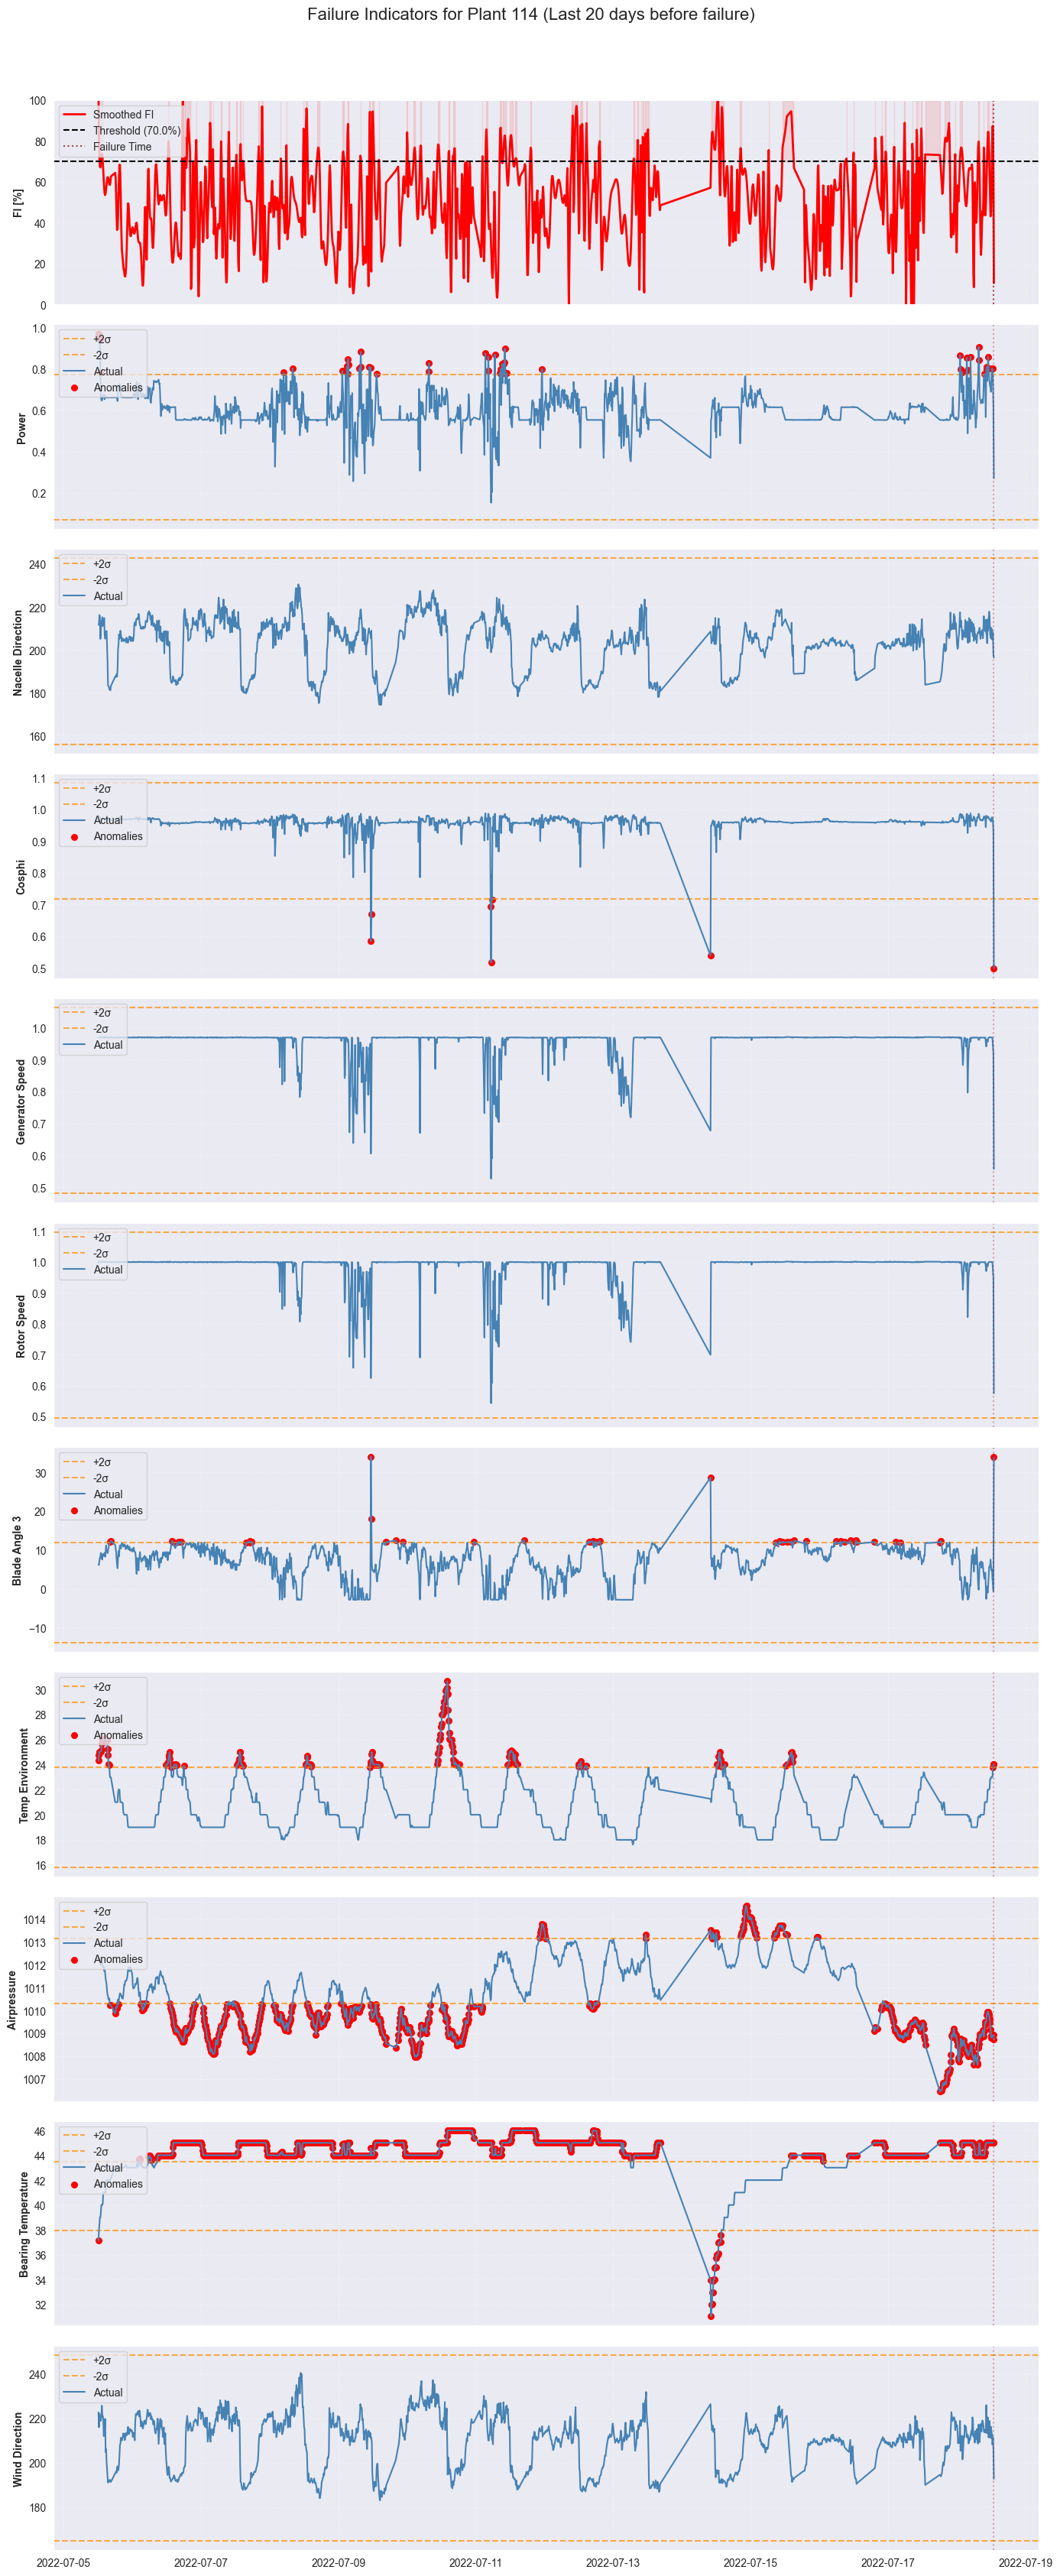


Key statistics near failure:
            power  nacelle_direction      cosphi  generator_speed  \
count  111.000000         111.000000  111.000000       111.000000   
mean     0.646153         207.431932    0.962625         0.958142   
std      0.104913           5.872437    0.045840         0.044411   
min      0.270394         185.147102    0.496875         0.557181   
25%      0.556879         205.218975    0.960345         0.966385   
50%      0.629557         207.876080    0.965395         0.969018   
75%      0.725675         210.543210    0.974257         0.969510   
max      0.905446         217.825958    0.987391         0.970623   

       rotor_speed  blade_angle_3  temp_environment  airpressure  \
count   111.000000     111.000000        111.000000   111.000000   
mean      0.987379       5.769286         20.326622  1008.342429   
std       0.045720       5.013985          1.101413     0.852761   
min       0.574686      -2.818637         19.000000  1006.429990   
25%     

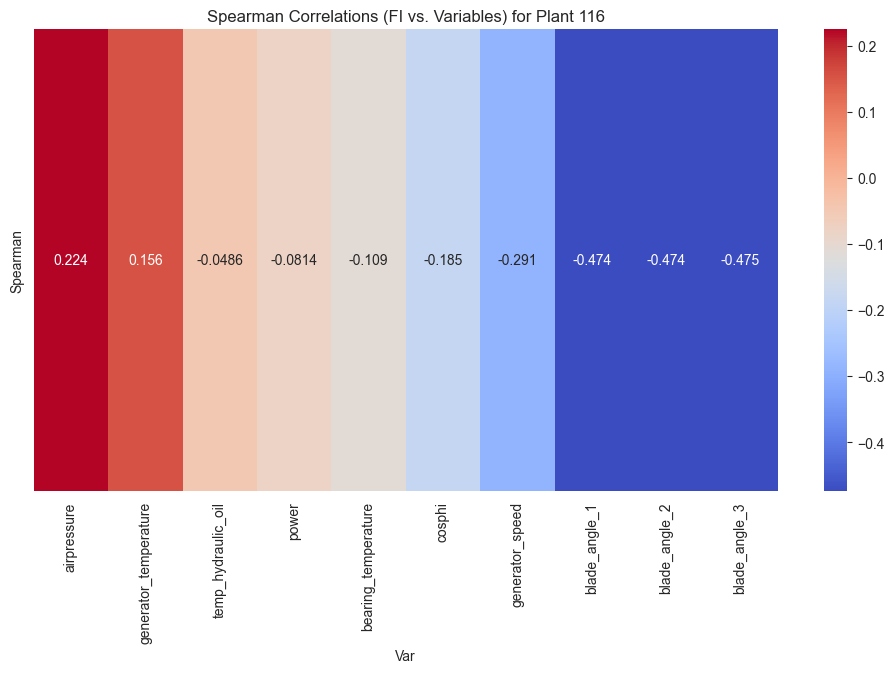

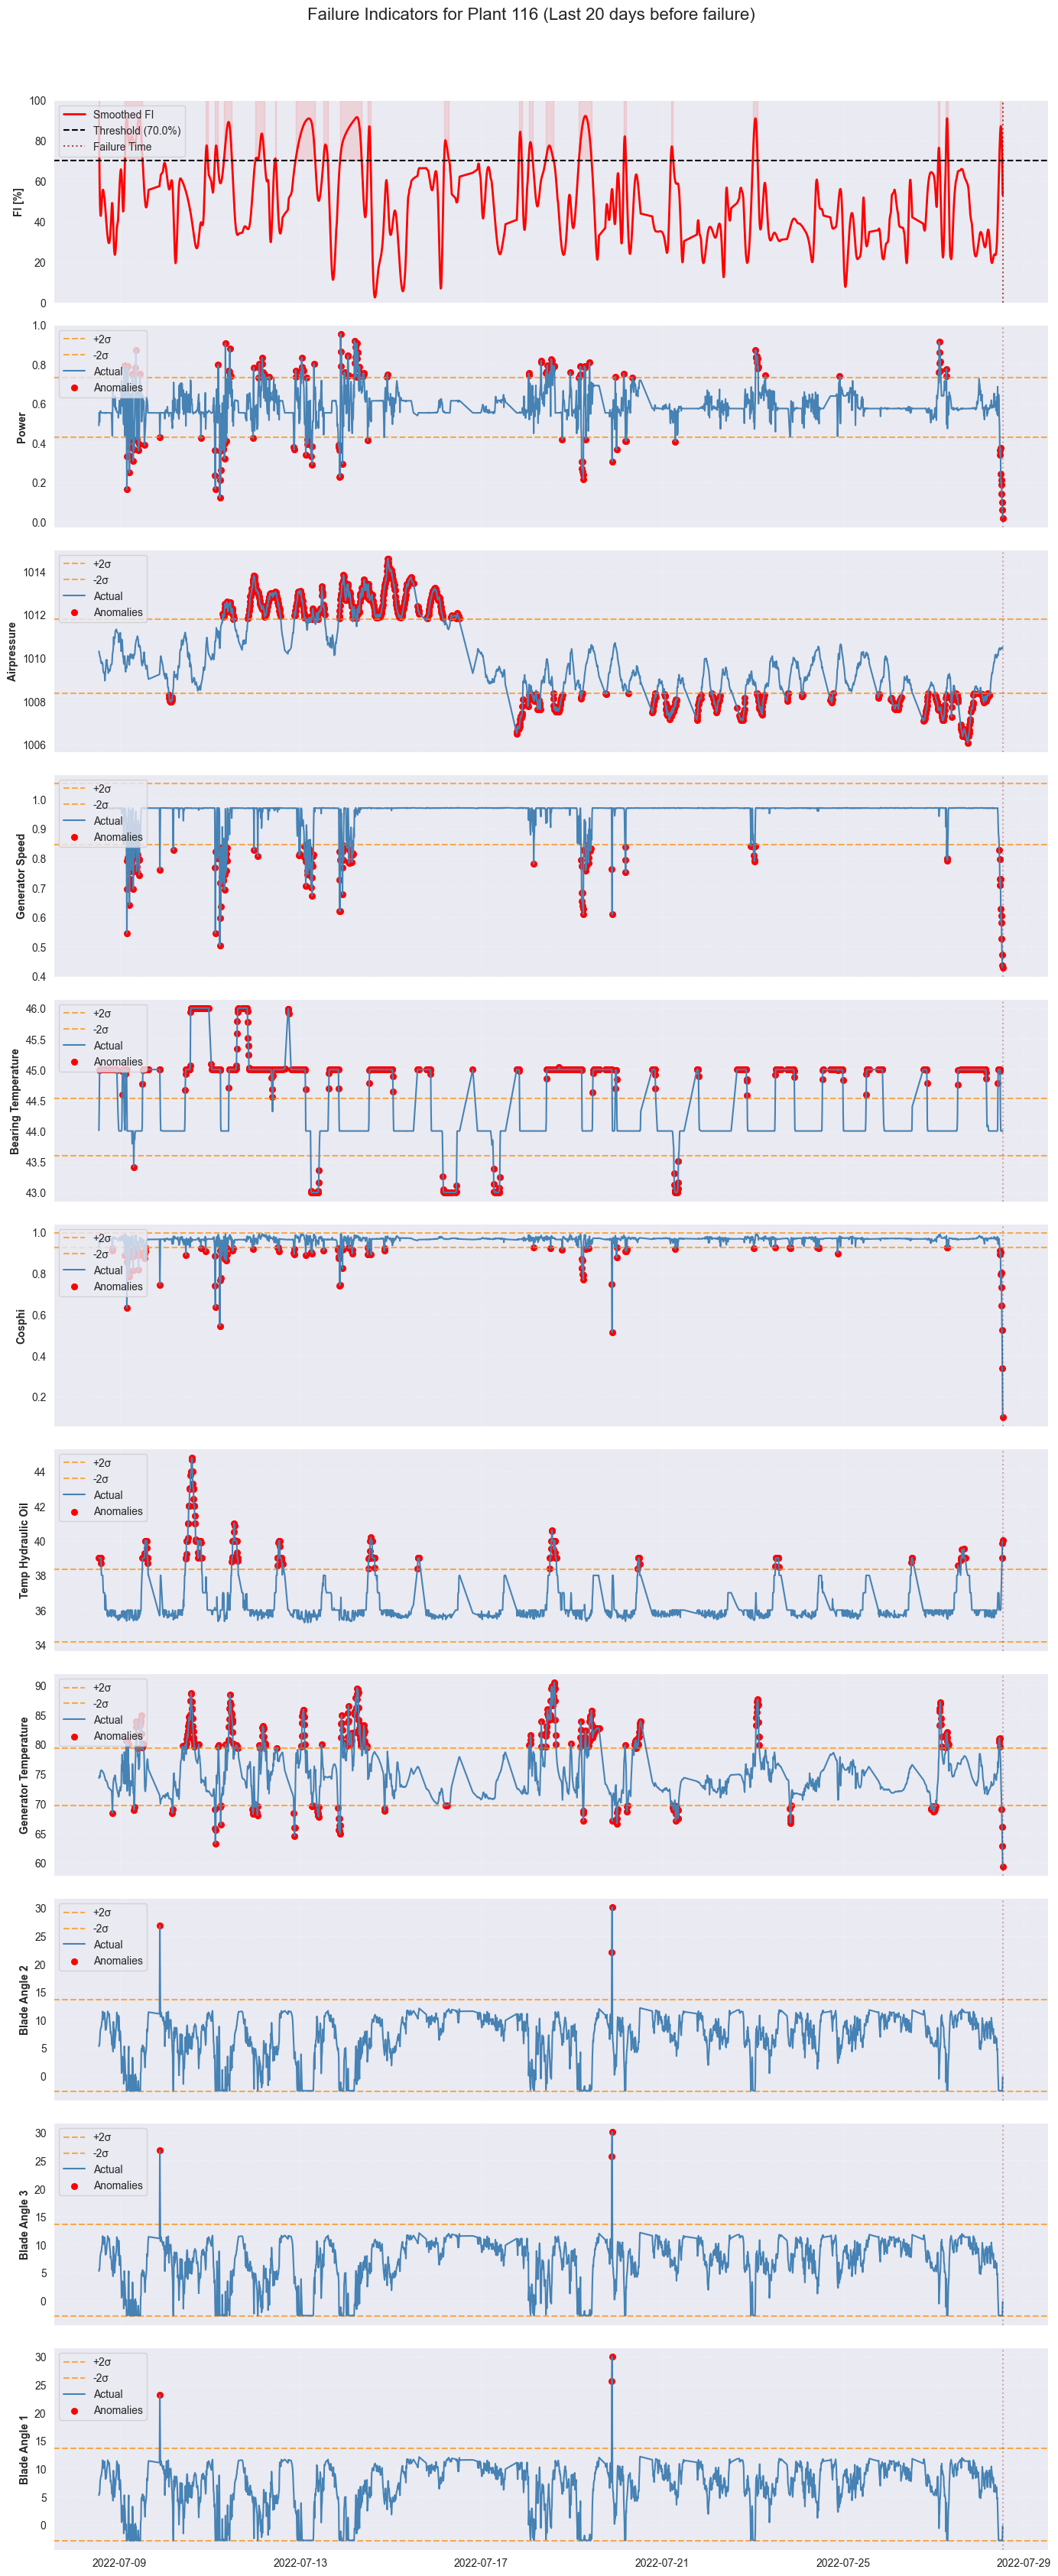


Key statistics near failure:
            power  airpressure  generator_speed  bearing_temperature  \
count  123.000000   123.000000       123.000000           123.000000   
mean     0.557326  1008.529837         0.933254            44.645922   
std      0.116854     1.208935         0.111586             0.467914   
min      0.016316  1006.060000         0.428216            44.000000   
25%      0.573286  1008.015015         0.968962            44.000000   
50%      0.575713  1008.390010         0.969355            45.000000   
75%      0.593165  1009.505005         0.969800            45.000000   
max      0.724438  1010.479980         0.970850            45.000000   

           cosphi  temp_hydraulic_oil  generator_temperature  blade_angle_2  \
count  123.000000          123.000000             123.000000     123.000000   
mean     0.941972           36.544216              74.539659       7.257738   
std      0.111134            1.175890               2.964566       4.130365   
min  

In [58]:
def tune_gmm_components(df, max_components=5):
    scaled_data = StandardScaler().fit_transform(df)
    transformed_data = norm.ppf(np.clip((rankdata(scaled_data, axis=0) - 0.5) / scaled_data.shape[0], 1e-6, 1 - 1e-6))

    bic_scores = []

    for n_comp in range(1, max_components + 1):
        gmm = GaussianMixture(n_components=n_comp, covariance_type='full', random_state=RANDOM_STATE)
        gmm.fit(transformed_data)
        bic_scores.append(gmm.bic(transformed_data))

    best_n_comp = np.argmin(bic_scores) + 1
    print(f"Optimal number of GMM components based on BIC: {best_n_comp}")
    return best_n_comp

sample_plant = list(last_failure_dates.keys())[0]
sample_df = data[data['plant_name'] == sample_plant]
sample_learn = clean_data(sample_df.loc[:last_failure_dates[sample_plant] - pd.Timedelta(days=TEST_PERIOD_DAYS)])

if not sample_learn.empty:
    sample_features = plant_specific_features.get(sample_plant, [])
    if sample_features:
        GMM_COMPONENTS = tune_gmm_components(sample_learn[sample_features])
    else:
        GMM_COMPONENTS = 3
else:
    GMM_COMPONENTS = 3

for plant_name, failure_date in last_failure_dates.items():
    print(f"\n======== Processing Plant: {plant_name} (Failure Date: {failure_date}) ========")
    plant_df = data[data['plant_name'] == plant_name].copy()

    test_start_date = failure_date - pd.Timedelta(days=TEST_PERIOD_DAYS)
    test_df_raw = plant_df.loc[test_start_date:failure_date].copy()
    learn_df_raw = plant_df.loc[:test_start_date].copy()

    learn_df = clean_data(learn_df_raw)
    test_df = clean_data(test_df_raw)

    selected_features = plant_specific_features.get(plant_name, [])
    available_vars = [v for v in selected_features if v in learn_df.columns and learn_df[v].nunique() > 1]

    if not available_vars:
        print("No valid features for FI calculation. Skipping plant.")
        continue

    learn_clean = learn_df[available_vars]
    test_clean = test_df[available_vars]

    scaler = StandardScaler()
    Xs_learn = scaler.fit_transform(learn_clean)
    constant_mask = np.std(Xs_learn, axis=0) == 0
    if np.any(constant_mask):
        print(f"Removing constant features: {np.array(available_vars)[constant_mask]}")
        Xs_learn = Xs_learn[:, ~constant_mask]
        Xs_test = scaler.transform(test_clean)[:, ~constant_mask]
        available_vars = list(np.array(available_vars)[~constant_mask])
    else:
        Xs_test = scaler.transform(test_clean)

    Z_learn = norm.ppf(np.clip((rankdata(Xs_learn, axis=0) - 0.5) / Xs_learn.shape[0], 1e-6, 1 - 1e-6))
    gmm = GaussianMixture(n_components=GMM_COMPONENTS, covariance_type='full', random_state=RANDOM_STATE)
    gmm.fit(Z_learn)

    Z_test = norm.ppf(np.clip((rankdata(Xs_test, axis=0) - 0.5) / Xs_test.shape[0], 1e-6, 1 - 1e-6))
    logp_test = gmm.score_samples(Z_test)
    FI_test = (1.0 - ((rankdata(logp_test) - 0.5) / len(logp_test))) * 100

    if len(FI_test) > 1:
        SPLINE_SMOOTHING_FACTOR = len(FI_test) * np.var(FI_test) * 0.5
        spl = UnivariateSpline(np.arange(len(FI_test)), FI_test, k=3, s=SPLINE_SMOOTHING_FACTOR)
        FI_test_s = spl(np.arange(len(FI_test)))
    else:
        FI_test_s = FI_test

    correlations = {}
    plot_vars = [v for v in available_vars if v in test_df.columns]
    for var in plot_vars:
        if test_df[var].nunique() > 1 and len(FI_test_s) > 1:
            rho, p_value = spearmanr(test_df[var], FI_test_s)
            correlations[var] = rho

    if correlations:
        corr_df = pd.DataFrame(list(correlations.items()), columns=['Var', 'Spearman'])
        corr_df = corr_df.sort_values(by='Spearman', ascending=False)
        plt.figure(figsize=(12, 6))
        sns.heatmap(corr_df.set_index('Var').T, annot=True, cmap='coolwarm', fmt=".3g")
        plt.title(f"Spearman Correlations (FI vs. Variables) for Plant {plant_name}")
        plt.show()

    n_vars_to_plot = min(10, len(plot_vars))
    fig, axes = plt.subplots(n_vars_to_plot + 1, 1, figsize=(14, 3 * (n_vars_to_plot + 1)), sharex=True)
    fig.suptitle(f"Failure Indicators for Plant {plant_name} (Last {TEST_PERIOD_DAYS} days before failure)",
                 fontsize=16, y=1.02)
    ax = axes[0]
    ax.plot(test_df.index, FI_test_s, color='red', linewidth=2, label='Smoothed FI')
    ax.axhline(FI_THRESHOLD, linestyle='--', color='black', label=f'Threshold ({FI_THRESHOLD}%)')
    ax.axvline(failure_date, color='darkred', linestyle=':', alpha=0.7, label='Failure Time')
    ax.fill_between(test_df.index, FI_THRESHOLD, 100, where=(FI_test_s >= FI_THRESHOLD), color='red', alpha=0.1)
    ax.set_ylabel('FI [%]', fontweight='bold')
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.legend(loc='upper left')
    ax.set_ylim(0, 100)

    for i, var in enumerate(plot_vars[:n_vars_to_plot], start=1):
        ax = axes[i]

        # New anomaly detection logic for specific time series
        if var == 'wind_speed':
            anomalies = esd_anomaly_detection(test_df[var], period_s=144, window_s_multiple=2)
            ax.set_ylabel(var.replace('_', ' ').title(), fontweight='bold')
            ax.plot(test_df.index, test_df[var], color='steelblue', label='Actual')
            ax.scatter(anomalies.index, anomalies.values, color='red', s=30, label='Anomalies')
            ax.grid(True, linestyle=':', alpha=0.5)
            ax.legend(loc='upper left')
        elif var == 'humidity' and len(learn_df[var]) > 100:
            lower_bound = learn_df[var].quantile(0.05)
            upper_bound = learn_df[var].quantile(0.95)
            anomalies = test_df[var][(test_df[var] < lower_bound) | (test_df[var] > upper_bound)]
            ax.axhline(upper_bound, color='darkorange', linestyle='--', alpha=0.7, label='95th Percentile')
            ax.axhline(lower_bound, color='darkorange', linestyle='--', alpha=0.7, label='5th Percentile')
            ax.set_ylabel(var.replace('_', ' ').title(), fontweight='bold')
            ax.plot(test_df.index, test_df[var], color='steelblue', label='Actual')
            ax.scatter(anomalies.index, anomalies.values, color='red', s=30, label='Anomalies')
            ax.grid(True, linestyle=':', alpha=0.5)
            ax.legend(loc='upper left')
        else:
            rolling_mean = learn_df[var].rolling('24h').mean()
            rolling_std = learn_df[var].rolling('24h').std()
            if rolling_std.iloc[-1] > 0:
                anomalies = test_df[var].loc[np.abs((test_df[var] - rolling_mean.iloc[-1]) / rolling_std.iloc[-1]) > 2]
                ax.axhline(rolling_mean.iloc[-1] + 2 * rolling_std.iloc[-1], color='darkorange', linestyle='--', alpha=0.7, label='+2σ')
                ax.axhline(rolling_mean.iloc[-1] - 2 * rolling_std.iloc[-1], color='darkorange', linestyle='--', alpha=0.7, label='-2σ')
            else:
                anomalies = pd.Series()
            ax.set_ylabel(var.replace('_', ' ').title(), fontweight='bold')
            ax.plot(test_df.index, test_df[var], color='steelblue', label='Actual')
            if not anomalies.empty:
                ax.scatter(anomalies.index, anomalies.values, color='red', s=30, label='Anomalies')
            ax.grid(True, linestyle=':', alpha=0.5)
            ax.legend(loc='upper left')

        ax.axvline(failure_date, color='darkred', linestyle=':', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("\nKey statistics near failure:")
    failure_window = test_df.last('24h')
    print(failure_window[plot_vars].describe())

    print("\nMaximum FI scores:")
    max_fi_idx = np.argsort(FI_test_s)[-3:]
    for idx in max_fi_idx:
        print(f"{test_df.index[idx]}: {FI_test_s[idx]:.1f}%")
        print(test_df.iloc[idx][plot_vars])

### Plant 109
*The model identified multiple strong warning signals on July 23, 2022, two days before the failure. At these moments, the FI scores were all above 106%, a very strong indication of an anomaly. The contributing factors included:

- Extremely High Temperatures: generator_temperature was extremely high, with values reaching over 92°C, and bearing_temperature was at its maximum of 45°C. These indicate significant overheating of key components.

- Low Wind Speed and High Power: Despite a low wind_speed (around 0.79), the power output was high (0.83–0.84). This suggests the turbine was being forced to operate at a high load in suboptimal wind conditions, potentially causing the overheating.

- Abnormal Blade Angles: The blade_angle values were negative, indicating a potential issue with the blade pitch control system. This could be a sign of the system attempting to compensate for the high power and low wind speed, or a mechanical failure.

### Plant 115
*The model provided an early warning for this turbine, with the highest FI scores occurring on July 19, 2022, a full nine days before the failure, and another on July 18. The model's key takeaways were:

- High Generator Temperature: Similar to Plant 109, the generator_temperature was extremely high (83–85°C) at these peak FI moments, a clear red flag.

- Low Rotor Speed and Power: Both rotor_speed and power were low, despite the high generator temperatures. This could indicate a power-generation component failure, where heat is being generated without a corresponding power output.

- Blade Pitch Issues: The highest FI score was accompanied by an extremely negative blade_angle value (-2.25), a strong sign of a serious control system malfunction.

### Plant 120
*This turbine showed an interesting pattern, with the model identifying high-FI moments on July 9 and July 5, 2022. This suggests a recurring pattern of stress that eventually led to failure.

- Varying Power and Temperature: The early FI spike on July 5 was characterized by very high power (0.95–0.96) and a relatively low generator_temperature, possibly indicating a period of high-stress operation. The later spike on July 9 showed a lower power output (0.94) but a very high generator_temperature (90°C), suggesting a shift toward an overheating problem.

- Elevated Bearing Temperatures: The bearing_temperature was high at 44°C during the July 9 warnings, which is a strong indicator of impending mechanical failure in the bearings.

### Plant 114
*The model successfully flagged multiple distinct periods of anomalous behavior for this turbine well before the failure on July 18, 2022.

- Highest FI Score: This turbine had an FI score of over 100% on July 5, 2022. This was a very significant anomaly driven by an extremely high power output (0.96), potentially an over-production event. The bearing temperature was at a normal level during this event, suggesting the initial stress was not thermal.

- High Bearing and Temperature Readings: The later warnings on July 14 and July 6 showed a different pattern. The FI spike on July 6 was accompanied by a maximum bearing_temperature of 45°C, while the July 14 warning showed a low bearing_temperature of 36°C, which is unusual. This highlights the model's ability to detect different types of anomalies, from mechanical to thermal, occurring at various times.


### Plant 116
*The model successfully flagged multiple distinct periods of anomalous behavior for this turbine well before the failure on July 18, 2022.

- Highest FI Score: This turbine had an FI score of over 100% on July 5, 2022. This was a very significant anomaly driven by an extremely high power output (0.96), potentially an over-production event. The bearing temperature was at a normal level during this event, suggesting the initial stress was not thermal.

- High Bearing and Temperature Readings: The later warnings on July 14 and July 6 showed a different pattern. The FI spike on July 6 was accompanied by a maximum bearing_temperature of 45°C, while the July 14 warning showed a low bearing_temperature of 36°C, which is unusual. This highlights the model's ability to detect different types of anomalies, from mechanical to thermal, occurring at various times.